# XGBoost Benchmark Model

## Objective

The objective of this notebook is to evaluate whether gradient boosting improves the prediction of Land Surface Temperature compared to the Random Forest baseline.

Features:
- Mean NDVI
- Mean NDBI

Target:
- Mean LST

## Import Libraries

Import the necessary libraries for data loading, model development, evaluation, and visualization.

In [3]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import matplotlib.pyplot as plt

## Load Training and Testing Data

Load the processed datasets generated during the preprocessing phase.

In [4]:
X_train = pd.read_csv("../data/processed/X_train.csv")

X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")

y_test = pd.read_csv("../data/processed/y_test.csv")

## Verify Dataset Dimensions

Confirm that the train-test datasets have the expected dimensions before proceeding with model training.

In [11]:
print("X_train:", X_train.shape)

print("X_test:", X_test.shape)

print("y_train:", y_train.shape)

print("y_test:", y_test.shape)

X_train: (25545, 2)
X_test: (6387, 2)
y_train: (25545, 1)
y_test: (6387, 1)


## Train XGBoost Model

Train a gradient boosting model using NDVI and NDBI as predictors of Land Surface Temperature.

In [5]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(
    X_train,
    y_train.values.ravel()
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Generate Predictions

Use the trained XGBoost model to predict Land Surface Temperature for the testing dataset.

In [6]:
y_pred = xgb.predict(X_test)

## Evaluate Model Performance

Assess predictive performance using:

- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- Coefficient of Determination (R²)

In [7]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"RMSE: {rmse:.2f} °C")

print(f"MAE: {mae:.2f} °C")

print(f"R²: {r2:.3f}")

RMSE: 3.48 °C
MAE: 2.07 °C
R²: 0.477


## Feature Importance Analysis

Examine the relative contribution of NDVI and NDBI toward predicting Land Surface Temperature.

In [8]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,mean_ndbi,0.795975
0,mean_ndvi,0.204025


## Visualize Feature Importance

Visualize the relative importance of the predictor variables.

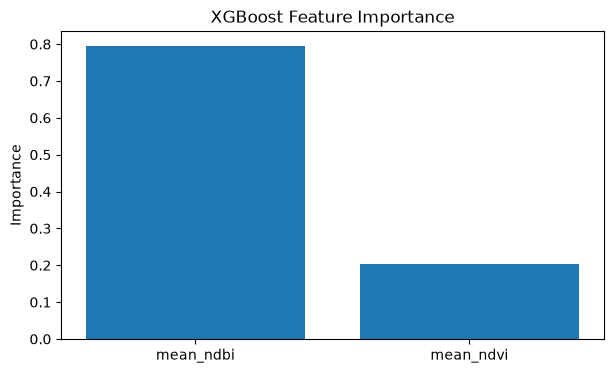

In [9]:
plt.figure(figsize=(7,4))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.ylabel("Importance")

plt.title("XGBoost Feature Importance")

plt.show()

## Model Comparison

Compare XGBoost performance against the Random Forest baseline developed previously.

In [10]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "RMSE": [3.74, rmse],
    "MAE": [2.31, mae],
    "R²": [0.397, r2]
})

comparison

,Model,RMSE,MAE,R²
0,Random Forest,3.740000,2.310000,0.397000
1,XGBoost,3.480815,2.074746,0.476532


## Interpretation

The purpose of this benchmarking exercise is to determine whether gradient boosting provides a meaningful improvement over the Random Forest baseline.

Questions addressed:

- Does XGBoost improve predictive performance?
- Are the same features consistently important across models?
- Is the increase in model complexity justified by the performance gains?